In [1]:
import numpy as np
import pandas as pd
from neuralprophet import NeuralProphet
from matplotlib import pyplot as plt
import pickle

In [2]:
df=pd.read_csv('D:\\paper\\C\\data\\5\\6data.csv')
df.head()

,date,Requests,Wind speed,solar hour,rel humid,temp
0,2013-01-01,826.666667,4.145161,374.8,38.0,17.4
1,2013-02-01,130.340909,4.567742,303.7,33.0,20.9
2,2013-03-01,101.216966,5.412903,337.4,22.0,28.6
3,2013-04-01,72.093023,5.374194,366.8,21.0,31.2
4,2013-05-01,37.959184,5.270968,348.1,22.0,31.1


In [3]:
#df.hour.unique()

In [4]:
df.columns

Index(['date', 'Requests', 'Wind speed', 'solar hour', 'rel humid', 'temp'], dtype='object')

In [5]:
df.dtypes

date           object
Requests      float64
Wind speed    float64
solar hour    float64
rel humid     float64
temp          float64
dtype: object

In [6]:
df["date"] = pd.to_datetime(df["date"])
df

,date,Requests,Wind speed,solar hour,rel humid,temp
0,2013-01-01,826.666667,4.145161,374.8,38.0,17.4
1,2013-02-01,130.340909,4.567742,303.7,33.0,20.9
2,2013-03-01,101.216966,5.412903,337.4,22.0,28.6
3,2013-04-01,72.093023,5.374194,366.8,21.0,31.2
4,2013-05-01,37.959184,5.270968,348.1,22.0,31.1
5,2013-06-01,56.479592,4.590323,337.5,20.0,28.9
6,2013-07-01,75.000000,4.153333,292.8,26.0,23.1
7,2013-08-01,1120.408163,3.470000,207.4,45.0,13.5
8,2013-09-01,2051.870748,3.060000,178.6,56.0,8.5
9,2013-10-01,2983.333333,2.733333,167.4,53.0,3.2


In [7]:
df.dtypes

date          datetime64[ns]
Requests             float64
Wind speed           float64
solar hour           float64
rel humid            float64
temp                 float64
dtype: object

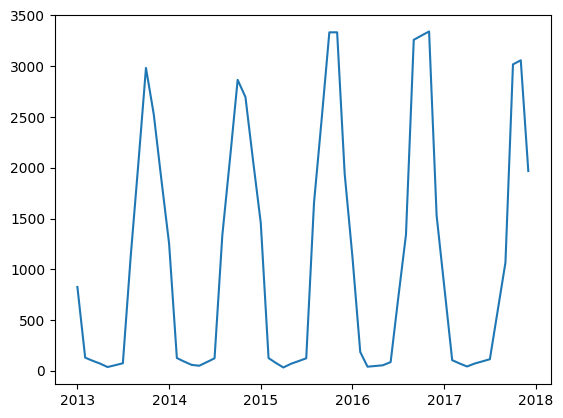

In [8]:
plt.plot(df["date"], df["Requests"])
plt.show()

In [9]:
#df["Year"] = df["date"].apply(lambda x: x.year)
#df = df[df["Year"]<=2014]
#plt.plot(df["date"], df["temp15"])
#plt.show

In [10]:
#df.tail()

In [11]:
null_pct=df.apply(pd.isnull).sum()/df.shape[0]


In [12]:
null_pct

date          0.0
Requests      0.0
Wind speed    0.0
solar hour    0.0
rel humid     0.0
temp          0.0
dtype: float64

In [13]:
valid_columns=df.columns[null_pct<0.05]

In [14]:
valid_columns

Index(['date', 'Requests', 'Wind speed', 'solar hour', 'rel humid', 'temp'], dtype='object')

In [15]:
df=df[valid_columns].copy()

In [16]:
df

,date,Requests,Wind speed,solar hour,rel humid,temp
0,2013-01-01,826.666667,4.145161,374.8,38.0,17.4
1,2013-02-01,130.340909,4.567742,303.7,33.0,20.9
2,2013-03-01,101.216966,5.412903,337.4,22.0,28.6
3,2013-04-01,72.093023,5.374194,366.8,21.0,31.2
4,2013-05-01,37.959184,5.270968,348.1,22.0,31.1
5,2013-06-01,56.479592,4.590323,337.5,20.0,28.9
6,2013-07-01,75.000000,4.153333,292.8,26.0,23.1
7,2013-08-01,1120.408163,3.470000,207.4,45.0,13.5
8,2013-09-01,2051.870748,3.060000,178.6,56.0,8.5
9,2013-10-01,2983.333333,2.733333,167.4,53.0,3.2


In [17]:
data = df[["date", "Requests"]]
data.dropna(inplace=True)
data.columns = ["ds", "y"]
data

WARNING - (py.warnings._showwarnmsg) - C:\Users\Vahid\AppData\Local\Programs\Python\Python37\lib\site-packages\pandas\util\_decorators.py:311: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return func(*args, **kwargs)



,ds,y
0,2013-01-01,826.666667
1,2013-02-01,130.340909
2,2013-03-01,101.216966
3,2013-04-01,72.093023
4,2013-05-01,37.959184
5,2013-06-01,56.479592
6,2013-07-01,75.000000
7,2013-08-01,1120.408163
8,2013-09-01,2051.870748
9,2013-10-01,2983.333333


In [18]:
#data = df[["Requests", "date"]]
#data.rename(columns={"date": "ds", "Requests": "y"}, inplace=True)

In [19]:
data

,ds,y
0,2013-01-01,826.666667
1,2013-02-01,130.340909
2,2013-03-01,101.216966
3,2013-04-01,72.093023
4,2013-05-01,37.959184
5,2013-06-01,56.479592
6,2013-07-01,75.000000
7,2013-08-01,1120.408163
8,2013-09-01,2051.870748
9,2013-10-01,2983.333333


In [20]:
#train model
m = NeuralProphet()
m.fit(data, freq="MS")

INFO - (NP.df_utils._infer_frequency) - Major frequency MS corresponds to 90.0% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - MS
INFO - (NP.config.init_data_params) - Setting normalization to global as only one dataframe provided for training.
INFO - (NP.utils.set_auto_seasonalities) - Disabling weekly seasonality. Run NeuralProphet with weekly_seasonality=True to override this.
INFO - (NP.utils.set_auto_seasonalities) - Disabling daily seasonality. Run NeuralProphet with daily_seasonality=True to override this.
INFO - (NP.config.set_auto_batch_epoch) - Auto-set batch_size to 16
INFO - (NP.config.set_auto_batch_epoch) - Auto-set epochs to 759
WARNING - (NP.config.set_lr_finder_args) - Learning rate finder: The number of batches (4) is too small than the required number for the learning rate finder (205). The results might not be optimal.


Finding best initial lr:   0%|          | 0/205 [00:00<?, ?it/s]

Training: 0it [00:00, ?it/s]

,MAE,RMSE,Loss,RegLoss,epoch
0,3371.067627,3883.312256,0.438884,0.0,0
1,3342.342773,3853.583008,0.437838,0.0,1
2,3307.142822,3837.176514,0.429356,0.0,2
3,3340.665283,3881.547363,0.436637,0.0,3
4,3366.873779,3889.309082,0.445496,0.0,4
...,...,...,...,...,...
754,157.050415,227.987946,0.002200,0.0,754
755,163.367432,234.446014,0.002396,0.0,755
756,158.430267,236.670624,0.002326,0.0,756
757,156.827240,229.836487,0.002177,0.0,757


In [21]:
m

In [28]:
#forcasting
future = m.make_future_dataframe(data, periods=36)
forecast = m.predict(future)
forecast

INFO - (NP.df_utils._infer_frequency) - Major frequency MS corresponds to 90.0% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - MS
INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column
INFO - (NP.df_utils._infer_frequency) - Major frequency MS corresponds to 88.889% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - MS
INFO - (NP.df_utils._infer_frequency) - Major frequency MS corresponds to 88.889% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - MS


Predicting: 4it [00:00, ?it/s]

INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column


,ds,y,yhat1,trend,season_yearly
0,2018-01-01,None,637.896057,686.358521,-48.462482
1,2018-02-01,None,-360.824646,643.680115,-1004.504761
2,2018-03-01,None,-462.750732,605.131897,-1067.882690
3,2018-04-01,None,-481.549591,562.453674,-1044.003296
4,2018-05-01,None,-567.875732,521.152161,-1089.027832
5,2018-06-01,None,-543.289246,478.473755,-1021.762939
6,2018-07-01,None,-472.758240,437.172089,-909.930298
7,2018-08-01,None,453.358704,394.493652,58.865059
8,2018-09-01,None,1378.114868,351.815613,1026.299194
9,2018-10-01,None,2358.653076,310.513733,2048.139404


In [29]:
forecast.tail()

,ds,y,yhat1,trend,season_yearly
31,2020-08-01,None,-613.787964,-611.889343,-1.898595
32,2020-09-01,None,464.386932,-654.567566,1118.954468
33,2020-10-01,None,1289.339600,-695.869263,1985.208862
34,2020-11-01,None,1273.099609,-738.547485,2011.647095
35,2020-12-01,None,-32.870880,-779.849182,746.978271


WARNING - (NP.plotting.log_warning_deprecation_plotly) - DeprecationWarning: default plotting_backend will be changed to plotly in a future version. Switch to plotly by calling `m.set_plotting_backend('plotly')`.


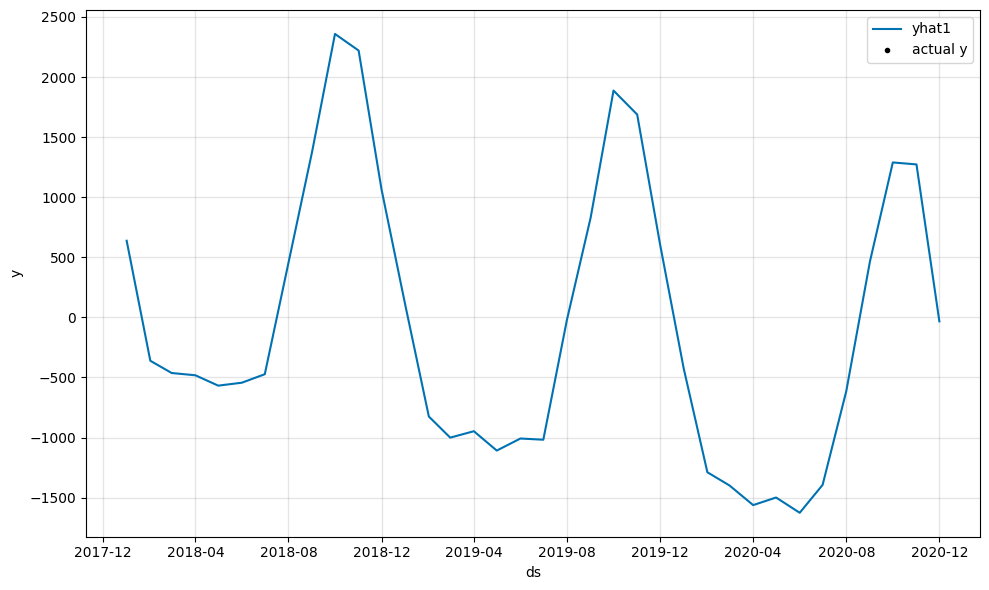

In [30]:
plot1 = m.plot(forecast)

WARNING - (NP.plotting.log_warning_deprecation_plotly) - DeprecationWarning: default plotting_backend will be changed to plotly in a future version. Switch to plotly by calling `m.set_plotting_backend('plotly')`.


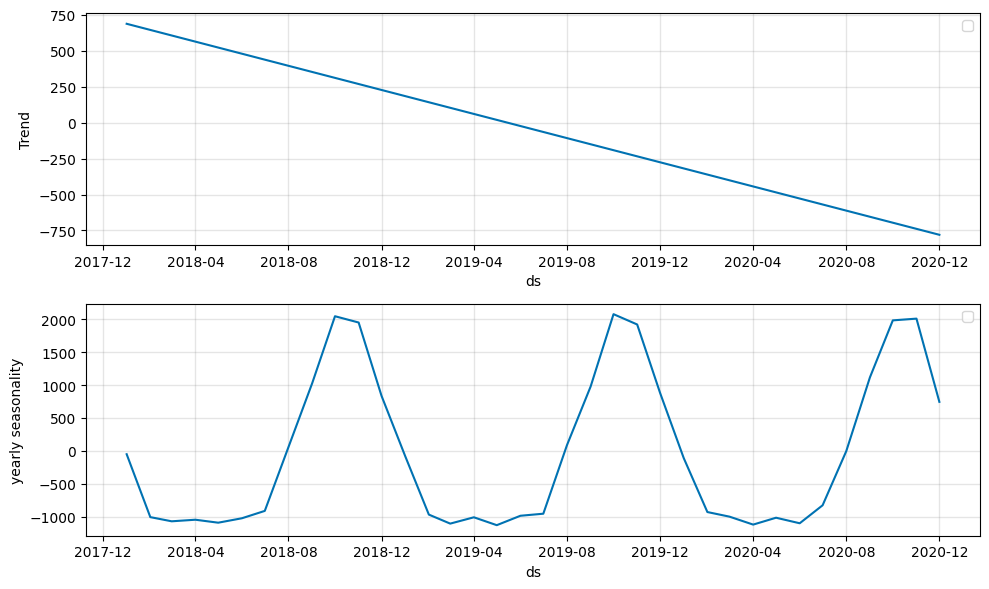

In [31]:
plot2 = m.plot_components(forecast)

In [32]:
#save model

with open("forecast_model.pk1", "wb") as f:
    pickle.dump(m, f)

In [33]:
m

In [34]:
del m

In [35]:
with open("forecast_model.pk1", "rb") as f:
      m = pickle.load(f)

In [36]:
m

In [37]:
#forcasting

future = m.make_future_dataframe(data, periods=10)
forecast = m.predict(future)
forecast

INFO - (NP.df_utils._infer_frequency) - Major frequency MS corresponds to 90.0% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - MS
INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column
INFO - (NP.df_utils._infer_frequency) - Major frequency MS corresponds to 80.0% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - MS
INFO - (NP.df_utils._infer_frequency) - Major frequency MS corresponds to 80.0% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - MS


AttributeError: 'Trainer' object has no attribute '_accelerator_connector'

WARNING - (NP.plotting.log_warning_deprecation_plotly) - DeprecationWarning: default plotting_backend will be changed to plotly in a future version. Switch to plotly by calling `m.set_plotting_backend('plotly')`.


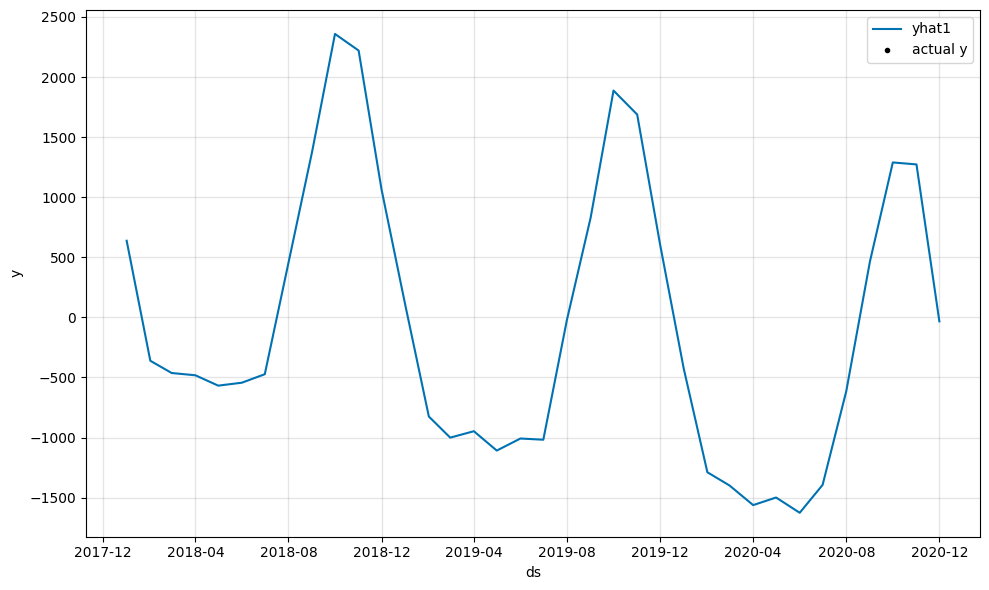

In [38]:
plot1 = m.plot(forecast)